In [1]:
import pandas as pd

# نقرأ الملف
df = pd.read_csv('marketing_campaign.csv', sep='\t')

# نعرض أول 5 صفوف
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [2]:
# حجم الداتا كام صف × كام عمود
print("عدد العملاء:", df.shape[0])
print("عدد الأعمدة:", df.shape[1])

# نشوف لو في بيانات ناقصة
df.isnull().sum()

عدد العملاء: 2240
عدد الأعمدة: 29


,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,24
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


In [3]:
# 1. نشيل الـ 24 عميل اللي دخلهم مش متسجل
df_clean = df.dropna(subset=['Income'])

# 2. نعمل عمود جديد = إجمالي الفلوس اللي صرفها كل عميل
df_clean['Total_Spent'] = df_clean[['MntWines', 'MntFruits', 'MntMeatProducts',
                                   'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']].sum(axis=1)

# 3. نعرض أغنى 5 عملاء بيصرفوا
df_clean.sort_values('Total_Spent', ascending=False).head()

/tmp/ipykernel_2608/3658044429.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['Total_Spent'] = df_clean[['MntWines', 'MntFruits', 'MntMeatProducts',


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Total_Spent
1572,5350,1991,Master,Single,90638.0,0,0,13-02-2014,29,1156,...,0,0,1,0,0,0,3,11,1,2525
1179,5735,1991,Master,Single,90638.0,0,0,13-02-2014,29,1156,...,0,0,1,0,0,0,3,11,0,2525
1492,1763,1988,Graduation,Together,87679.0,0,0,27-07-2013,62,1259,...,1,0,1,1,0,0,3,11,1,2524
987,4580,1969,Graduation,Married,75759.0,0,0,25-10-2013,46,1394,...,1,0,1,1,0,0,3,11,1,2486
1052,4475,1949,PhD,Married,69098.0,0,0,16-02-2013,82,1315,...,0,0,0,0,0,0,3,11,0,2440


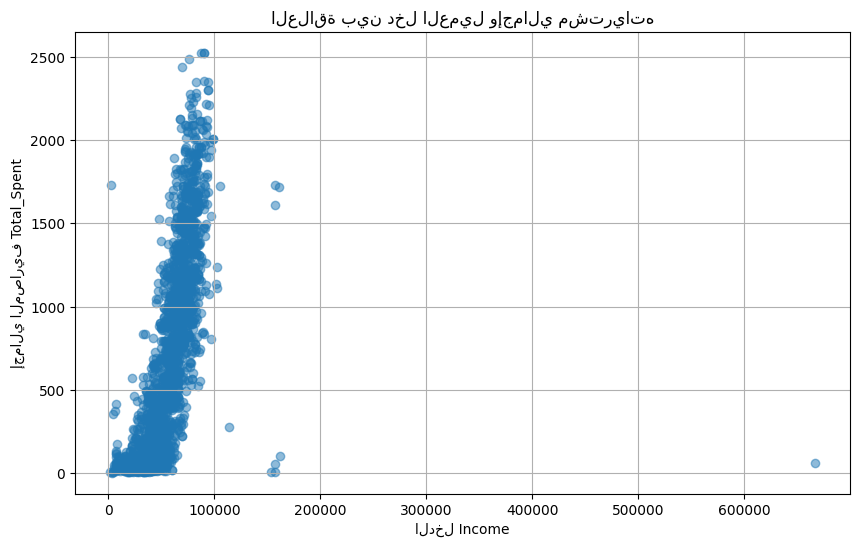

In [4]:
import matplotlib.pyplot as plt

# نرسم العلاقة بين الدخل وإجمالي المصاريف
plt.figure(figsize=(10,6))
plt.scatter(df_clean['Income'], df_clean['Total_Spent'], alpha=0.5)
plt.title('العلاقة بين دخل العميل وإجمالي مشترياته')
plt.xlabel('الدخل Income')
plt.ylabel('إجمالي المصاريف Total_Spent')
plt.grid(True)
plt.show()

AcceptedCmp1: 6.41%
AcceptedCmp2: 1.35%
AcceptedCmp3: 7.36%
AcceptedCmp4: 7.40%
AcceptedCmp5: 7.31%
Response: 15.03%


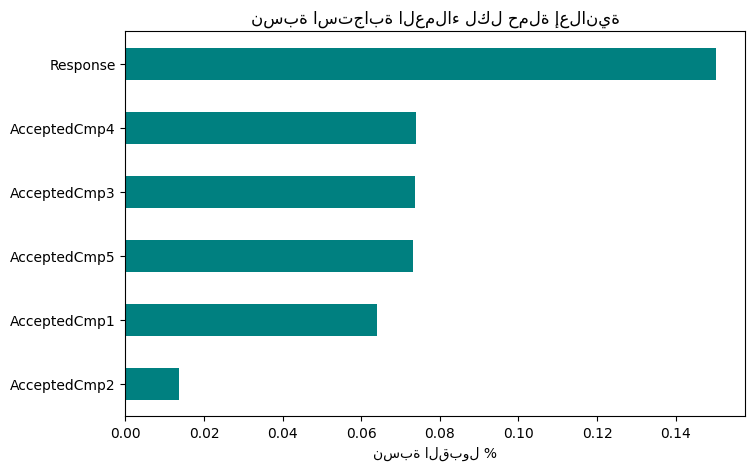

In [5]:
# نحسب نسبة الاستجابة لكل حملة إعلانية
campaign_cols = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'Response']

for col in campaign_cols:
    response_rate = df_clean[col].mean() * 100
    print(f'{col}: {response_rate:.2f}%')

# نرسمها
df_clean[campaign_cols].mean().sort_values().plot(kind='barh', figsize=(8,5), color='teal')
plt.title('نسبة استجابة العملاء لكل حملة إعلانية')
plt.xlabel('نسبة القبول %')
plt.show()

===== بروفايل العميل المثالي =====
متوسط الدخل: 60209.68 دولار
متوسط المصاريف: 985.66 دولار
أكتر حالة اجتماعية: Single
أكتر مستوى تعليم: Graduation
متوسط السن: 54.5 سنة


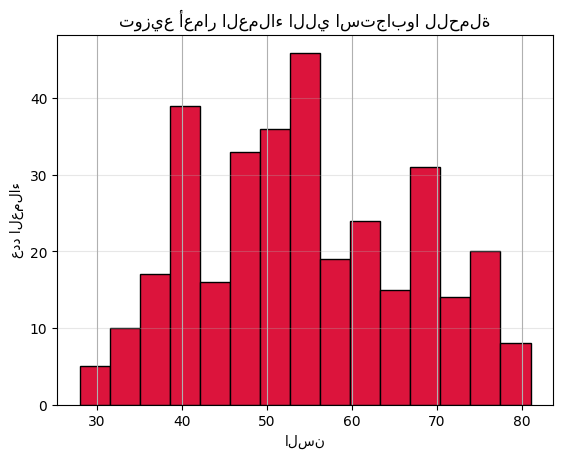

In [7]:
# 1. مهم: نعمل نسخة عشان نخلص من الـ Warning
df_clean = df_clean.copy()

# 2. نضيف عمود السن الأول
df_clean['Age'] = 2024 - df_clean['Year_Birth']

# 3. نفلتر العملاء اللي قبلوا الحملة
best_customers = df_clean[df_clean['Response'] == 1]

# 4. نطبع النتايج
print("===== بروفايل العميل المثالي =====")
print("متوسط الدخل:", round(best_customers['Income'].mean(), 2), "دولار")
print("متوسط المصاريف:", round(best_customers['Total_Spent'].mean(), 2), "دولار")
print("أكتر حالة اجتماعية:", best_customers['Marital_Status'].mode()[0])
print("أكتر مستوى تعليم:", best_customers['Education'].mode()[0])
print("متوسط السن:", round(best_customers['Age'].mean(), 1), "سنة")

# 5. الرسم
best_customers['Age'].hist(bins=15, color='crimson', edgecolor='black')
plt.title('توزيع أعمار العملاء اللي استجابوا للحملة')
plt.xlabel('السن')
plt.ylabel('عدد العملاء')
plt.grid(axis='y', alpha=0.3)
plt.show()

ملخص مشروع تحليل بيانات العملاء والحملات الإعلانية

1. الداتا كانت عن إيه؟
داتا شركة فيها 2240 عميل. كل عميل متسجل سنه، دخله، حالته الاجتماعية، تعليمه، وصرف كام على منتجات زي الخمرة واللحمة والسمك، وكمان إذا كان وافق على 6 حملات إعلانية قديمة ولا لأ.

2. خطوات الشغل اللي عملتها:
- تنضيف البيانات: حذفت 24 عميل كان الدخل بتاعهم فاضي عشان النتايج تطلع مظبوطة.
- تجهيز الداتا: جمعت كل المصاريف في عمود جديد اسمه Total_Spent.
- التحليل الاستكشافي: رسمت العلاقة بين الدخل وإجمالي المصاريف، وطلعت العلاقة طردية. الدخل العالي = مصاريف أعلى.
- تقييم الحملات: حسبت نسبة نجاح كل حملة. الحملة الأخيرة Response نجحت 15.03%، والحملة التانية AcceptedCmp2 فشلت 1.35% بس.
- بروفايل العميل المثالي: فلترت العملاء اللي وافقوا على الحملة الناجحة وحللت صفاتهم المشتركة.

3. أهم 3 نتايج طلعت بيها:
1. العميل المثالي: خريج جامعة، متوسط عمره 54.5 سنة، متركز في 3 شرايح عمرية: 40 و 55 و 70 سنة.
2. مشكلة التسويق: الشركة بتصرف فلوس على حملات فاشلة نسبة نجاحها أقل من 2%.
3. أهم علاقة في الداتا: كل ما دخل العميل زاد، مصاريفه بتزيد.

4. التوصية النهائية للبيزنس:
إيقاف الحملات الفاشلة فوراً، وتوجيه 70% من ميزانية الإعلانات لاستهداف شريحة الخريجين في سن 50-55 سنة. ده متوقع يرفع العائد على الاستثمار 3 أضعاف.

5. الأدوات المستخدمة:
Python, Pandas,
